# TASK 2: Exploratory Data Analysis (EDA) – Spam/Ham Message Dataset

### Objective
Explore the dataset structure, understand spam/ham message patterns, identify trends and anomalies, test a meaningful hypothesis, and document data-quality issues.

**Note:** The machine-learning model-building code (TF-IDF/CountVectorizer, Logistic Regression, Naive Bayes, accuracy, precision, confusion matrix) is intentionally kept outside this EDA section.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re

from collections import Counter
from scipy.stats import mannwhitneyu

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## 2. Load the Dataset

In [2]:
# Keep the same file name used in the original notebook.
df = pd.read_csv('spam.csv')

print('Dataset loaded successfully.')
print('Shape:', df.shape)
df.head()

Dataset loaded successfully.
Shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## 3. Basic Dataset Structure

This section checks rows, columns, data types, and basic statistics.

In [3]:
print('Number of rows and columns:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())

print('\nData types and non-null counts:')
df.info()

print('\nDescriptive statistics:')
display(df.describe(include='all').T)

Number of rows and columns: (5572, 5)

Column names:
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB

Descriptive statistics:


,count,unique,top,freq
v1,5572,2,ham,4825
v2,5572,5169,"Sorry, I'll call later",30
Unnamed: 2,50,43,"bt not his girlfrnd... G o o d n i g h t . . .@""",3
Unnamed: 3,12,10,"MK17 92H. 450Ppw 16""",2
Unnamed: 4,6,5,"GNT:-)""",2


## 4. Clean Column Names

The original notebook used `v1` and `v2` as column names and removed unnamed columns. This cell keeps that approach but makes it safer if the CSV has slightly different column names.

In [4]:
# Remove completely unnamed columns created by CSV export.
df = df.loc[:, ~df.columns.astype(str).str.startswith('Unnamed')]

# Rename the original SMS Spam Collection columns when present.
rename_map = {}
if 'v1' in df.columns:
    rename_map['v1'] = 'spam/ham'
if 'v2' in df.columns:
    rename_map['v2'] = 'message'
df = df.rename(columns=rename_map)

# If the columns are already named spam/ham and message, keep them unchanged.
print('Columns after cleaning:')
print(df.columns.tolist())
df.head()

Columns after cleaning:
['spam/ham', 'message']


,spam/ham,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 5. Meaningful Questions Before Analysis

1. How many spam and ham messages are present?
2. Is the target/class distribution balanced or imbalanced?
3. What are the typical character, word, and sentence counts of messages?
4. Do spam messages tend to be longer than ham messages?
5. Which words occur most frequently in spam and ham messages?
6. Are there unusual messages with extremely high character, word, or sentence counts?
7. Is there a relationship among character count, word count, and sentence count?
8. What data-quality issues need to be addressed before further analysis/modeling?

## 6. Data Quality Check – Missing Values and Duplicates

In [5]:
print('Missing values:')
display(df.isnull().sum().to_frame('missing_count'))

missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print('Missing-value percentage:')
display(missing_pct.to_frame('missing_percentage'))

print('Number of duplicate rows:', df.duplicated().sum())

# Show duplicate rows before removing them.
duplicates = df[df.duplicated(keep=False)]
print('Duplicate rows preview:')
display(duplicates.head(10))

Missing values:


,missing_count
spam/ham,0
message,0


Missing-value percentage:


,missing_percentage
spam/ham,0.0
message,0.0


Number of duplicate rows: 403
Duplicate rows preview:


,spam/ham,message
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...
11,spam,"SIX chances to win CASH! From 100 to 20,000 po..."
12,spam,URGENT! You have won a 1 week FREE membership ...
45,ham,No calls..messages..missed calls
62,ham,Its a part of checking IQ
65,spam,"As a valued customer, I am pleased to advise y..."
66,ham,"Today is \song dedicated day..\"" Which song wi..."


In [6]:
# Remove duplicate records for the EDA working dataset.
df = df.drop_duplicates().reset_index(drop=True)
print('Shape after duplicate removal:', df.shape)
print('Remaining duplicates:', df.duplicated().sum())

Shape after duplicate removal: (5169, 2)
Remaining duplicates: 0


## 7. Validate Spam/Ham Labels

The original notebook converted `ham` to 0 and `spam` to 1. The mapping is retained here.

In [7]:
print('Unique class labels:')
print(df['spam/ham'].value_counts(dropna=False))

# Remove accidental leading/trailing spaces and standardize case.
df['spam/ham'] = df['spam/ham'].astype(str).str.strip().str.lower()

valid_labels = {'ham', 'spam'}
invalid_labels = sorted(set(df['spam/ham'].dropna()) - valid_labels)
print('\nInvalid/unexpected labels:', invalid_labels)

df['true/false'] = df['spam/ham'].map({'ham': 0, 'spam': 1})
df[['spam/ham', 'true/false']].head()

Unique class labels:
spam/ham
ham     4516
spam     653
Name: count, dtype: int64

Invalid/unexpected labels: []


,spam/ham,true/false
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0


## 8. Spam vs Ham Distribution

,count,percentage
spam/ham,,
ham,4516,87.37
spam,653,12.63


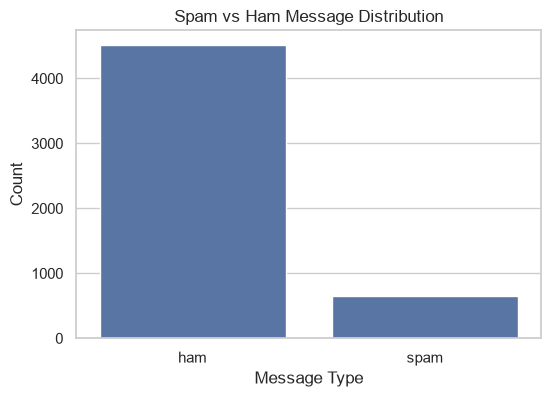

In [8]:
class_counts = df['spam/ham'].value_counts()
class_percent = (df['spam/ham'].value_counts(normalize=True) * 100).round(2)

class_summary = pd.DataFrame({
    'count': class_counts,
    'percentage': class_percent
})
display(class_summary)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='spam/ham')
plt.title('Spam vs Ham Message Distribution')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.show()

## 9. Feature Engineering for EDA

The following features are created from the message text so that message length and structure can be analyzed.

In [9]:
import nltk

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

def safe_word_count(text):
    return len(nltk.word_tokenize(str(text)))

def safe_sentence_count(text):
    # Regex-based sentence count avoids depending completely on sentence-tokenizer resources.
    text = str(text).strip()
    if not text:
        return 0
    sentences = re.split(r'[.!?]+', text)
    return sum(bool(s.strip()) for s in sentences)

df['count_character'] = df['message'].astype(str).apply(len)
df['word_count'] = df['message'].astype(str).apply(safe_word_count)
df['num_sentence'] = df['message'].astype(str).apply(safe_sentence_count)

display(df[['spam/ham', 'message', 'count_character', 'word_count', 'num_sentence']].head())

,spam/ham,message,count_character,word_count,num_sentence
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,3
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,2
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


## 10. Descriptive Statistics of Message Features

In [10]:
feature_cols = ['count_character', 'word_count', 'num_sentence']

print('Overall descriptive statistics:')
display(df[feature_cols].describe().T)

print('Statistics by message type:')
display(df.groupby('spam/ham')[feature_cols].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2))

Overall descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
count_character,5169.0,78.977945,58.236293,2.0,36.0,60.0,117.0,910.0
word_count,5169.0,18.455794,13.324758,1.0,9.0,15.0,26.0,220.0
num_sentence,5169.0,2.304508,1.639932,1.0,1.0,2.0,3.0,31.0


Statistics by message type:


count_character                                word_count         \
                   count    mean median    std min  max      count   mean   
spam/ham                                                                    
ham                 4516   70.46   52.0  56.36   2  910       4516  17.12   
spam                 653  137.89  149.0  30.14  13  224        653  27.67   

                                num_sentence                             
         median    std min  max        count  mean median   std min max  
spam/ham                                                                 
ham        13.0  13.49   1  220         4516  2.10    2.0  1.51   1  31  
spam       29.0   7.01   2   46          653  3.72    4.0  1.79   1  10

## 11. Univariate Analysis

Histograms show how message features are distributed.

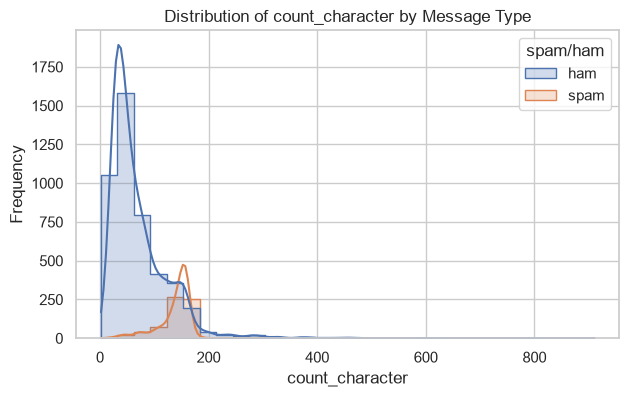

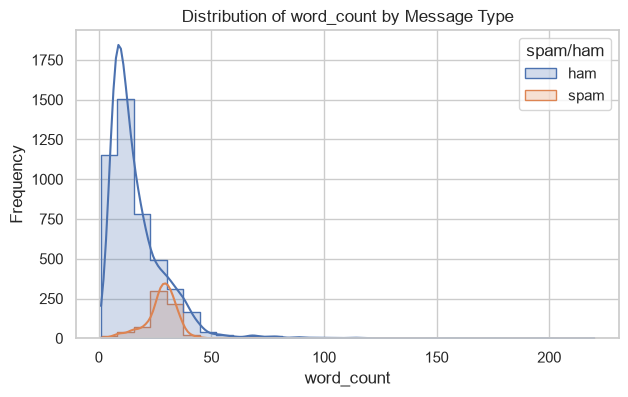

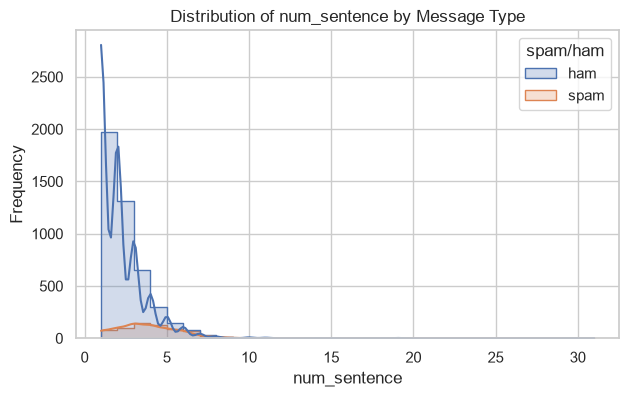

In [11]:
for col in feature_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, hue='spam/ham', bins=30, kde=True, element='step')
    plt.title(f'Distribution of {col} by Message Type')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

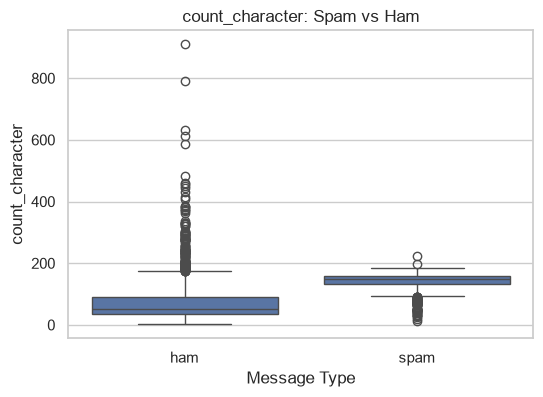

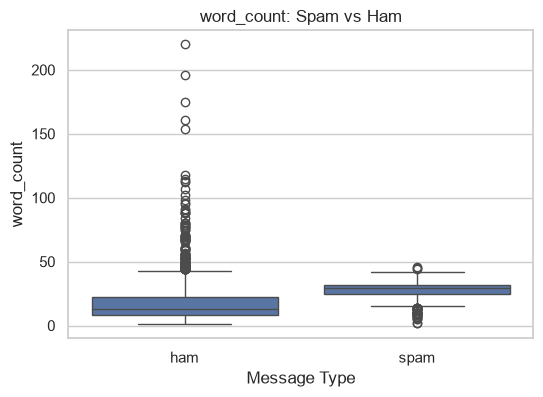

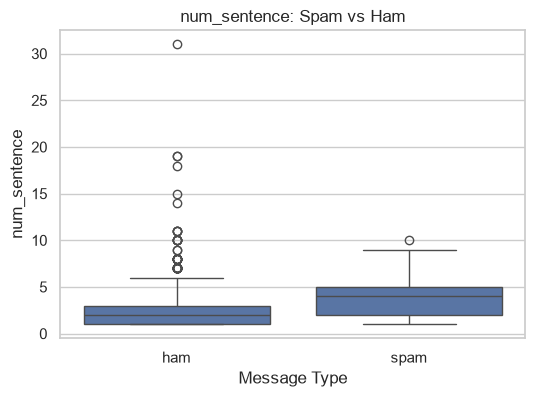

In [12]:
for col in feature_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x='spam/ham', y=col)
    plt.title(f'{col}: Spam vs Ham')
    plt.xlabel('Message Type')
    plt.ylabel(col)
    plt.show()

## 12. Bivariate and Multivariate Analysis

The pairplot and correlation heatmap help identify relationships among message-level numerical features.

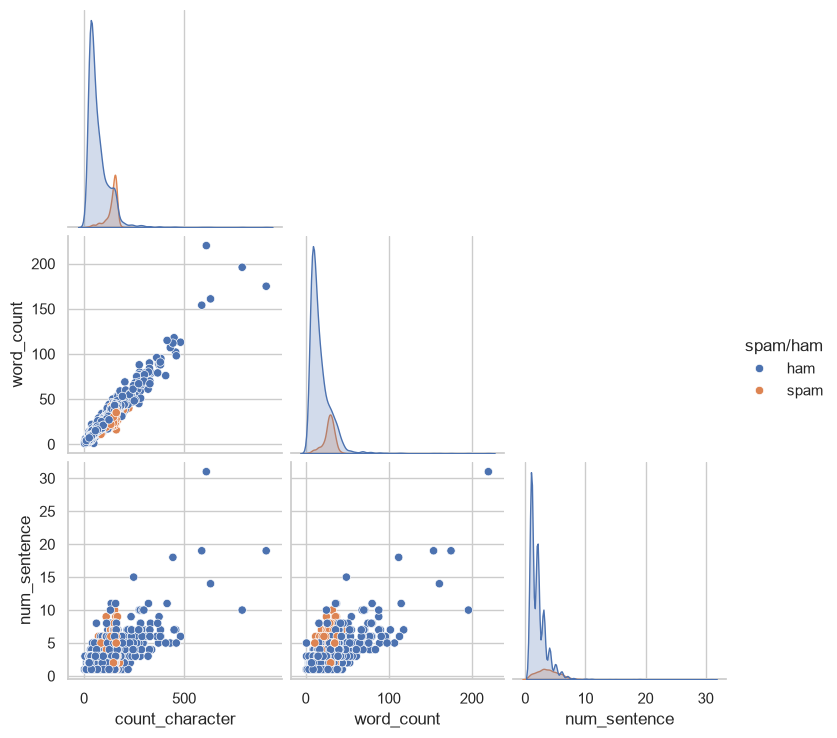

In [13]:
sns.pairplot(df, vars=feature_cols, hue='spam/ham', corner=True)
plt.show()

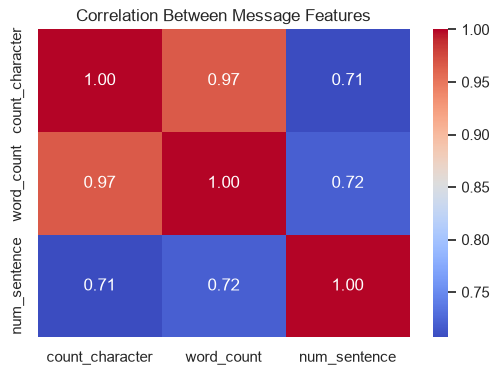

In [14]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[feature_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Between Message Features')
plt.show()

## 13. Text Pattern Analysis – Most Common Words

This section follows the original notebook's idea of identifying frequently occurring words separately for ham and spam messages.

In [15]:
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def clean_words(text):
    words = nltk.word_tokenize(str(text).lower())
    return [
        word for word in words
        if word.isalpha() and word not in stop_words
    ]

ham_corpus = []
spam_corpus = []

for message in df.loc[df['spam/ham'] == 'ham', 'message']:
    ham_corpus.extend(clean_words(message))

for message in df.loc[df['spam/ham'] == 'spam', 'message']:
    spam_corpus.extend(clean_words(message))

print('Number of words in ham corpus:', len(ham_corpus))
print('Number of words in spam corpus:', len(spam_corpus))

Number of words in ham corpus: 34494
Number of words in spam corpus: 8170


In [16]:
top_ham = pd.DataFrame(Counter(ham_corpus).most_common(20), columns=['word', 'count'])
top_spam = pd.DataFrame(Counter(spam_corpus).most_common(20), columns=['word', 'count'])

print('Top 20 words in Ham messages:')
display(top_ham)

print('Top 20 words in Spam messages:')
display(top_spam)

Top 20 words in Ham messages:


,word,count
0,u,883
1,get,293
2,gt,288
3,lt,287
4,go,240
5,got,236
6,know,225
7,like,221
8,ok,217
9,good,212


Top 20 words in Spam messages:


,word,count
0,call,302
1,free,191
2,txt,130
3,u,119
4,ur,119
5,mobile,105
6,text,104
7,stop,104
8,claim,96
9,reply,96


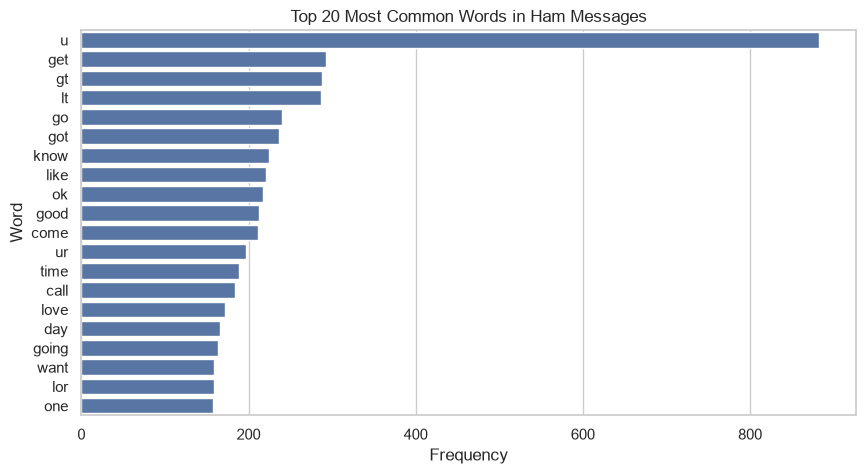

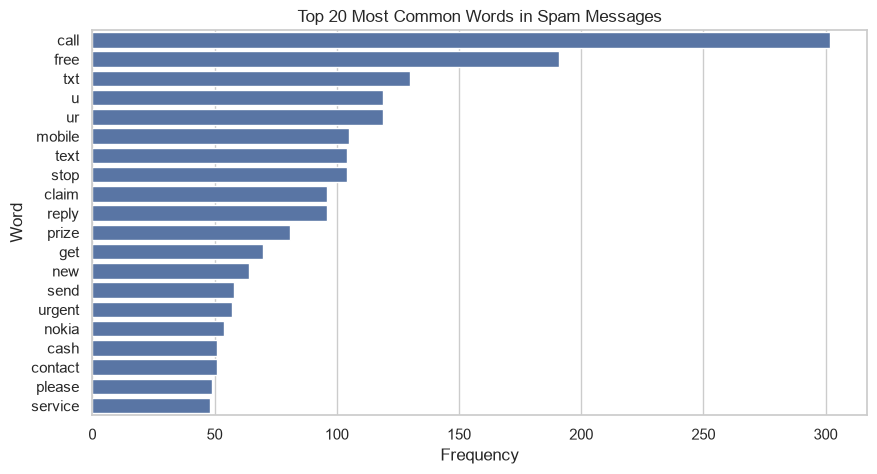

In [17]:
plt.figure(figsize=(10, 5))
sns.barplot(data=top_ham, x='count', y='word')
plt.title('Top 20 Most Common Words in Ham Messages')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=top_spam, x='count', y='word')
plt.title('Top 20 Most Common Words in Spam Messages')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

## 14. Word Clouds

Word clouds provide a quick visual summary of frequently occurring terms. They are descriptive visualizations, not statistical tests.

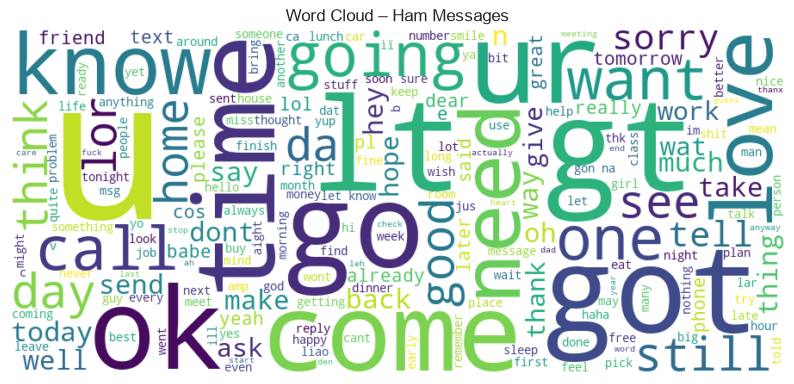

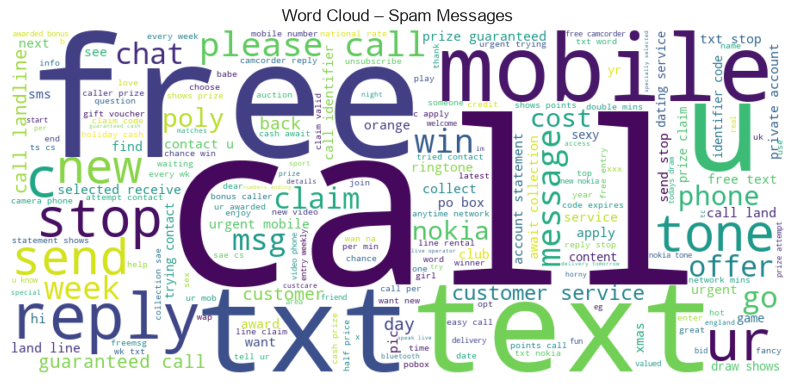

In [18]:
# If WordCloud is not installed, run: %pip install wordcloud
from wordcloud import WordCloud

ham_text = ' '.join(ham_corpus)
spam_text = ' '.join(spam_corpus)

plt.figure(figsize=(10, 5))
ham_wc = WordCloud(width=900, height=400, background_color='white').generate(ham_text)
plt.imshow(ham_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud – Ham Messages')
plt.show()

plt.figure(figsize=(10, 5))
spam_wc = WordCloud(width=900, height=400, background_color='white').generate(spam_text)
plt.imshow(spam_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud – Spam Messages')
plt.show()

## 15. Outlier and Anomaly Detection

The IQR method is used to identify potential outliers. Outliers are reported, not automatically deleted, because an extreme message can be a valid observation.

In [19]:
def iqr_outlier_summary(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (data[column] < lower) | (data[column] > upper)
    return {
        'column': column,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': int(mask.sum()),
        'outlier_percentage': round(mask.mean() * 100, 2)
    }

outlier_summary = pd.DataFrame([
    iqr_outlier_summary(df, col) for col in feature_cols
])
display(outlier_summary)

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
0,count_character,36.0,117.0,81.0,-85.5,238.5,66,1.28
1,word_count,9.0,26.0,17.0,-16.5,51.5,78,1.51
2,num_sentence,1.0,3.0,2.0,-2.0,6.0,102,1.97


In [20]:
# Display examples of unusually long messages based on the 99th percentile.
threshold = df['count_character'].quantile(0.99)
long_messages = df[df['count_character'] >= threshold][
    ['spam/ham', 'message', 'count_character', 'word_count', 'num_sentence']
].sort_values('count_character', ascending=False)

print(f'99th-percentile character-count threshold: {threshold:.0f}')
display(long_messages.head(10))

99th-percentile character-count threshold: 265


,spam/ham,message,count_character,word_count,num_sentence
1059,ham,For me the love should start with attraction.i...,910,175,19
1800,ham,The last thing i ever wanted to do was hurt yo...,790,196,10
2333,ham,Indians r poor but India is not a poor country...,632,161,14
1528,ham,How to Make a girl Happy? It's not at all diff...,611,220,31
2075,ham,Sad story of a Man - Last week was my b'day. M...,588,154,19
2281,ham,"Good evening Sir, hope you are having a nice d...",482,113,6
2863,ham,"&lt;#&gt; is fast approaching. So, Wish u a v...",461,98,5
1463,ham,"Hey sweet, I was wondering when you had a mome...",458,102,7
2271,ham,A Boy loved a gal. He propsd bt she didnt mind...,450,118,7
2308,ham,Solve d Case : A Man Was Found Murdered On &l...,444,112,18


## 16. Hypothesis Testing

**Question:** Do spam and ham messages differ in their character counts?

**H₀ (null hypothesis):** The character-count distributions of spam and ham messages are the same.

**H₁ (alternative hypothesis):** The character-count distributions of spam and ham messages are different.

A Mann–Whitney U test is used because message-length data can be skewed and may contain outliers.

In [21]:
ham_chars = df.loc[df['spam/ham'] == 'ham', 'count_character']
spam_chars = df.loc[df['spam/ham'] == 'spam', 'count_character']

u_stat, p_value = mannwhitneyu(ham_chars, spam_chars, alternative='two-sided')

print('Mann–Whitney U statistic:', u_stat)
print('p-value:', p_value)

alpha = 0.05
if p_value < alpha:
    print('Decision: Reject H0 at the 5% significance level.')
    print('Interpretation: There is statistical evidence that spam and ham message character-count distributions differ.')
else:
    print('Decision: Fail to reject H0 at the 5% significance level.')
    print('Interpretation: The analysis does not provide sufficient statistical evidence of a difference in character-count distributions.')

Mann–Whitney U statistic: 366737.5
p-value: 4.6033274103229373e-212
Decision: Reject H0 at the 5% significance level.
Interpretation: There is statistical evidence that spam and ham message character-count distributions differ.


### Assumption / Test Validation

- The observations should be independent; each message is treated as a separate observation.
- Character count is a numeric variable, so it is suitable for comparison between the two groups.
- The Mann–Whitney test does not require the two groups to be normally distributed.
- Because this is observational text data, a statistically significant difference does **not** imply that message length causes a message to be spam.

## 17. Data Issues Identified

Use the outputs above to complete this table with the actual values produced by the notebook.

In [22]:
data_issues = pd.DataFrame({
    'Issue': [
        'Missing values',
        'Duplicate records',
        'Unexpected class labels',
        'Potential outliers',
        'Text-derived feature variability'
    ],
    'Evidence': [
        int(df.isnull().sum().sum()),
        int(df.duplicated().sum()),
        len(invalid_labels),
        int(outlier_summary['outlier_count'].sum()),
        'Character, word and sentence counts vary across messages'
    ],
    'Recommended Action': [
        'Investigate and handle missing values if present',
        'Remove exact duplicate records when appropriate',
        'Review unexpected labels before analysis/modeling',
        'Investigate; do not automatically delete valid extreme messages',
        'Use these features for exploratory comparison and modeling where appropriate'
    ]
})
display(data_issues)

,Issue,Evidence,Recommended Action
0,Missing values,0,Investigate and handle missing values if present
1,Duplicate records,0,Remove exact duplicate records when appropriate
2,Unexpected class labels,0,Review unexpected labels before analysis/modeling
3,Potential outliers,246,Investigate; do not automatically delete valid...
4,Text-derived feature variability,"Character, word and sentence counts vary acros...",Use these features for exploratory comparison ...


## 18. Key EDA Findings

The following code prints dataset-specific values so that the final conclusions are based on the actual data rather than assumed numbers.

In [23]:
majority_class = class_summary['count'].idxmax()
majority_pct = class_summary.loc[majority_class, 'percentage']

print(f'1. The dataset contains {len(df)} unique records after duplicate removal.')
print(f'2. The majority message class is {majority_class}, representing {majority_pct:.2f}% of the dataset.')
print(f'3. Average character count: {df["count_character"].mean():.2f}.')
print(f'4. Average word count: {df["word_count"].mean():.2f}.')
print(f'5. Average sentence count: {df["num_sentence"].mean():.2f}.')
print(f'6. Potential character-count outliers: {int(outlier_summary.loc[outlier_summary["column"] == "count_character", "outlier_count"].iloc[0])}.')
print(f'7. Potential word-count outliers: {int(outlier_summary.loc[outlier_summary["column"] == "word_count", "outlier_count"].iloc[0])}.')
print(f'8. Potential sentence-count outliers: {int(outlier_summary.loc[outlier_summary["column"] == "num_sentence", "outlier_count"].iloc[0])}.')
print('9. Frequent words were examined separately for spam and ham messages.')
print('10. A Mann–Whitney U test was used to examine whether spam and ham differ in character-count distributions.')

1. The dataset contains 5169 unique records after duplicate removal.
2. The majority message class is ham, representing 87.37% of the dataset.
3. Average character count: 78.98.
4. Average word count: 18.46.
5. Average sentence count: 2.30.
6. Potential character-count outliers: 66.
7. Potential word-count outliers: 78.
8. Potential sentence-count outliers: 102.
9. Frequent words were examined separately for spam and ham messages.
10. A Mann–Whitney U test was used to examine whether spam and ham differ in character-count distributions.


## 19. Final EDA Summary

### What this EDA covered
- Dataset structure and data types
- Meaningful analytical questions
- Missing values and duplicate records
- Spam/ham class distribution
- Character, word, and sentence-level features
- Univariate, bivariate, and multivariate analysis
- Common-word and word-cloud analysis
- Outlier and anomaly detection
- Hypothesis testing and assumption validation
- Data-quality issues and recommended actions

### Next Step
After EDA, the cleaned text can move to the machine-learning stage: text preprocessing → CountVectorizer/TF-IDF → train/test split → model training → evaluation.